# Importing our libraries

In [1]:
import numpy as np
import zipfile
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns

# Importing our dataset

In [2]:
df = pd.read_csv('diabetes.csv')

print(df.head())
print("Shape:", df.shape)
print(df.columns)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape: (768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [5]:
df.describe().round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


## Key Observations from Statistical Summary
- Glucose, Insulin, BMI, BloodPressure, SkinThickness have **minimum values of 0** — medically impossible, confirming need for imputation
- Insulin has very high std (115) indicating extreme spread
- Age ranges from 21–81 with mean ~33, skewed younger
- Only 34.9% of patients are diabetic (class imbalance)

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Checking class distribution

In [5]:
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## Check invalid zeros

In [6]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
for i in cols:
    print(df[i].unique())


[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]
[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]
[35 29  0 23 32 45 19 47 38 30 41 33 26 15 36 11 31 37 42 25 18 24 39 27
 21 34 10 60 13 20 22 28 54 40 51 56 14 17 50 44 12 46 16  7 52 43 48  8
 49 63 99]
[  0  94 168  88 543 846 175 230  83  96 235 

In [7]:
for col in cols:
    print(col, (df[col] == 0).sum())

print(df.columns)

Pregnancies 111
Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11
DiabetesPedigreeFunction 0
Age 0
Outcome 500
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


# Dataset Ranges

In [8]:
df.groupby('Outcome').agg(['min','median','mean','max'])

Pregnancies                      Glucose                          \
                min median      mean max     min median        mean  max   
Outcome                                                                    
0                 0    2.0  3.298000  13       0  107.0  109.980000  197   
1                 0    4.0  4.865672  17       0  140.0  141.257463  199   

        BloodPressure         ...        BMI       DiabetesPedigreeFunction  \
                  min median  ...       mean   max                      min   
Outcome                       ...                                             
0                   0   70.0  ...  30.304200  57.3                    0.078   
1                   0   74.0  ...  35.142537  67.1                    0.088   

                                Age                        
        median      mean    max min median       mean max  
Outcome                                                    
0        0.336  0.429734  2.329  21   27.0  31.190000  81  
1        0.449  0.550500  2.420  21   36.0  37.067164  70  

[2 rows x 32 columns]

# KDE Plots per feature split by Outcome

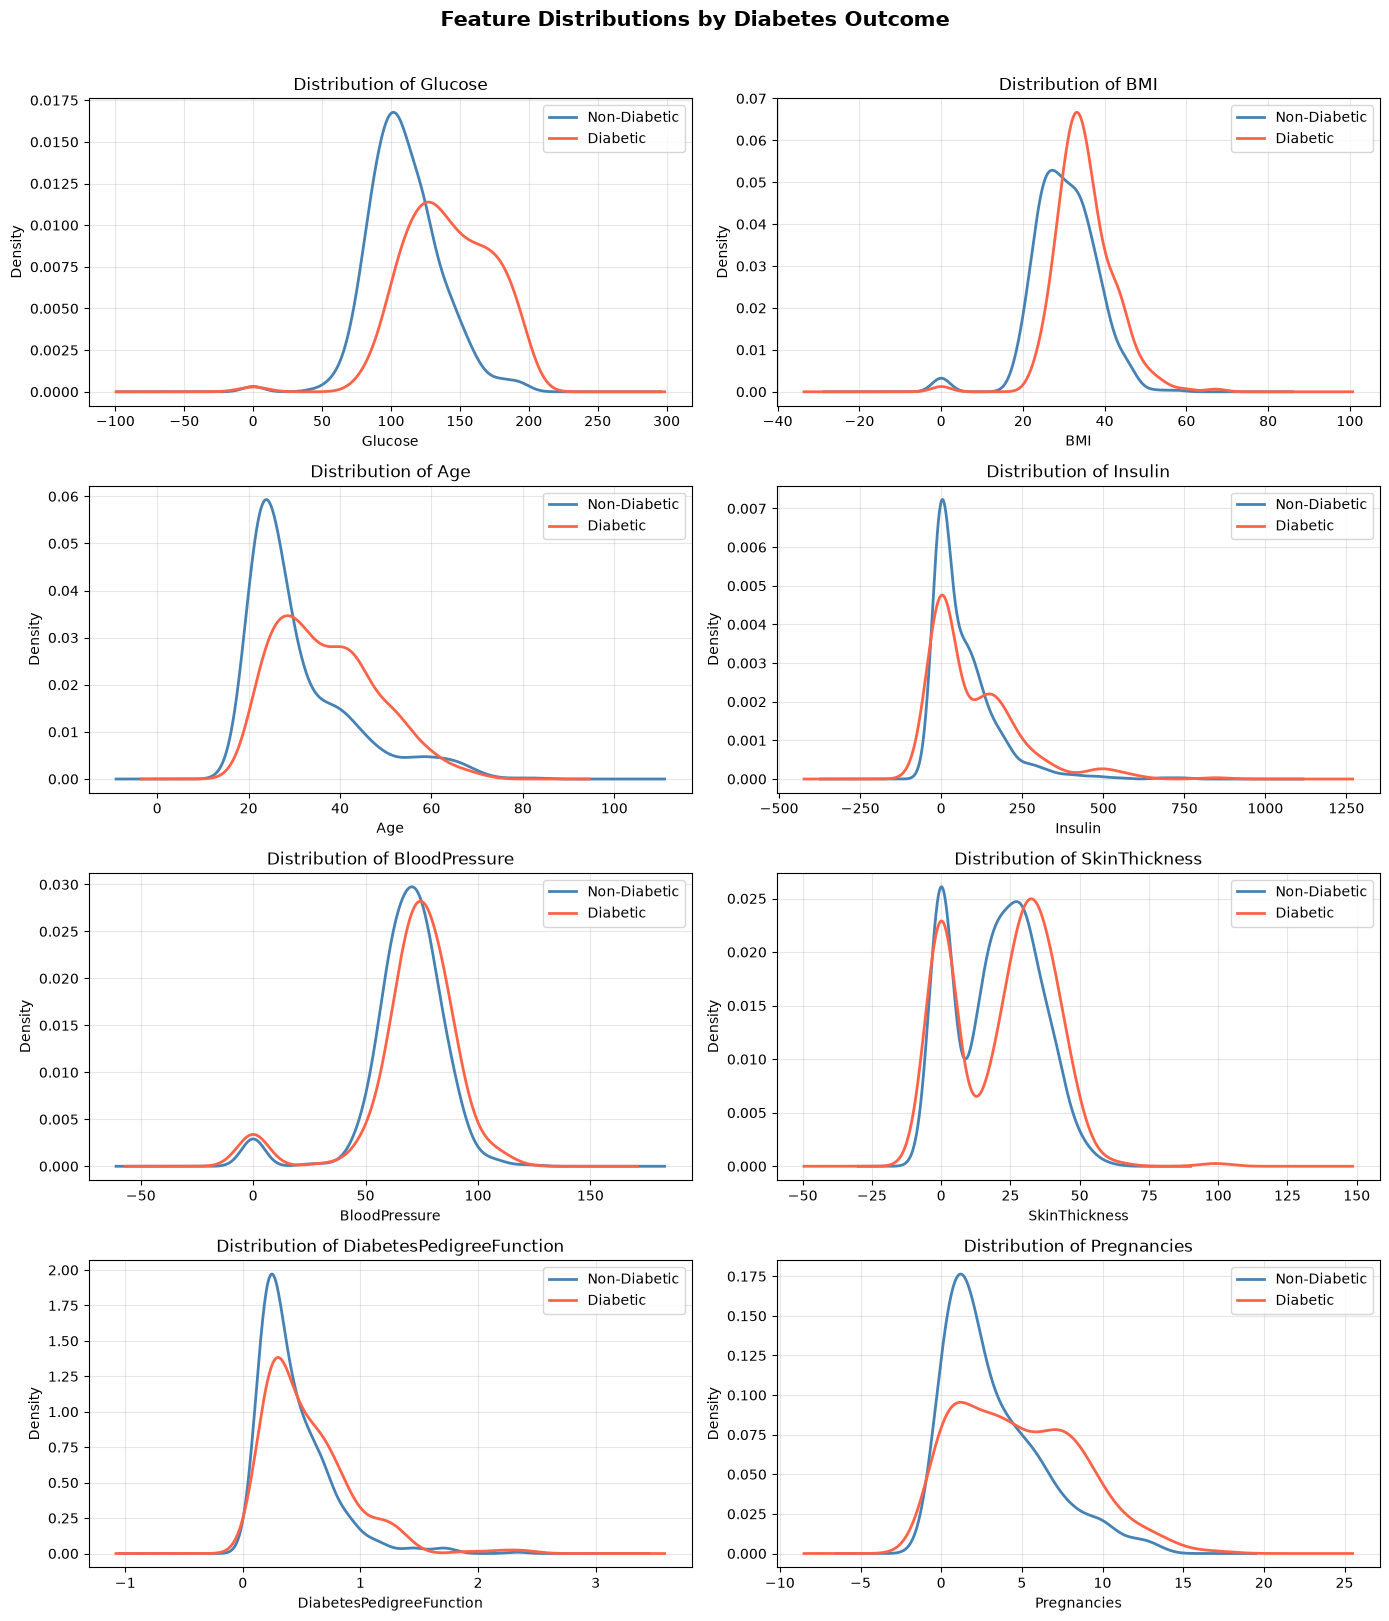

In [10]:
features = ['Glucose', 'BMI', 'Age', 'Insulin',
            'BloodPressure', 'SkinThickness',
            'DiabetesPedigreeFunction', 'Pregnancies']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    df[df['Outcome'] == 0][feature].plot.kde(ax=axes[i], label='Non-Diabetic', color='steelblue', linewidth=2)
    df[df['Outcome'] == 1][feature].plot.kde(ax=axes[i], label='Diabetic',     color='tomato',    linewidth=2)
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kde_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## KDE Plot Observations
- **Glucose** shows the clearest separation — diabetic patients are heavily right-shifted, making it the strongest individual predictor
- **BMI** shows moderate separation — higher BMI correlates with diabetes but distributions overlap significantly
- **Age** — diabetic patients skew older, though many young patients are also affected
- **Insulin** — both groups have similar peaks but diabetic group has a heavier right tail
- **DiabetesPedigreeFunction** — slight rightward shift in diabetics, confirming genetic factor relevance
- **BloodPressure & SkinThickness** — minimal separation, likely weaker predictors individually
- **Pregnancies** — diabetic group shows higher pregnancy counts on average

# Correlation Heatmap

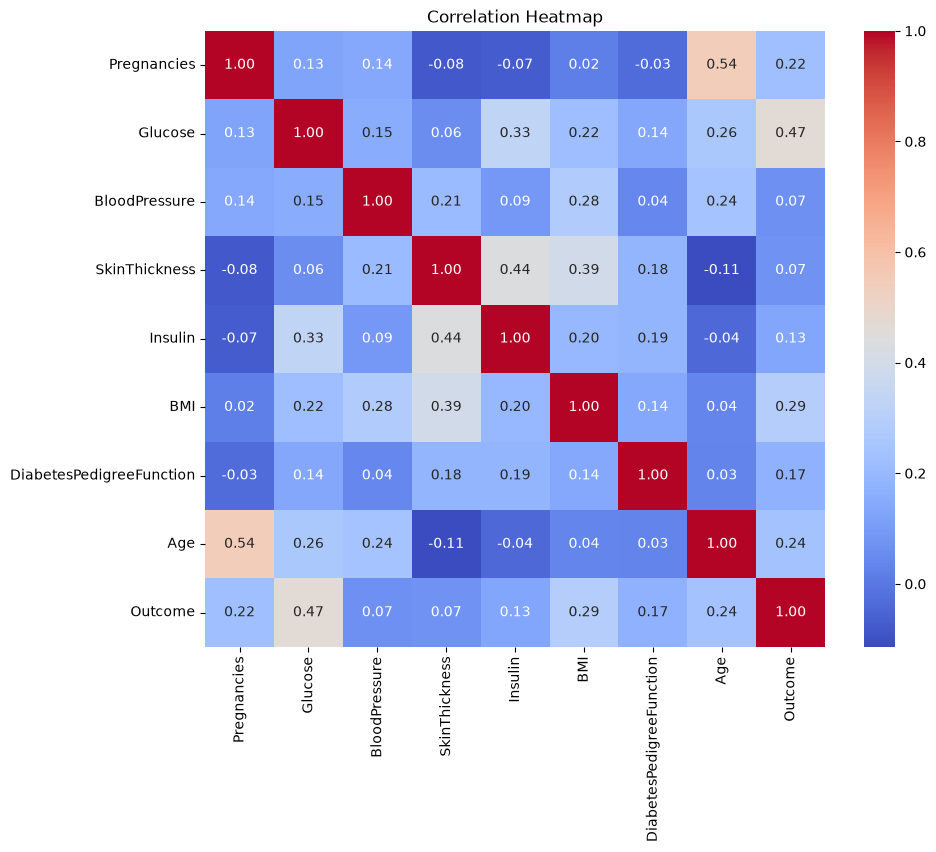

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

## Outcome Distribution

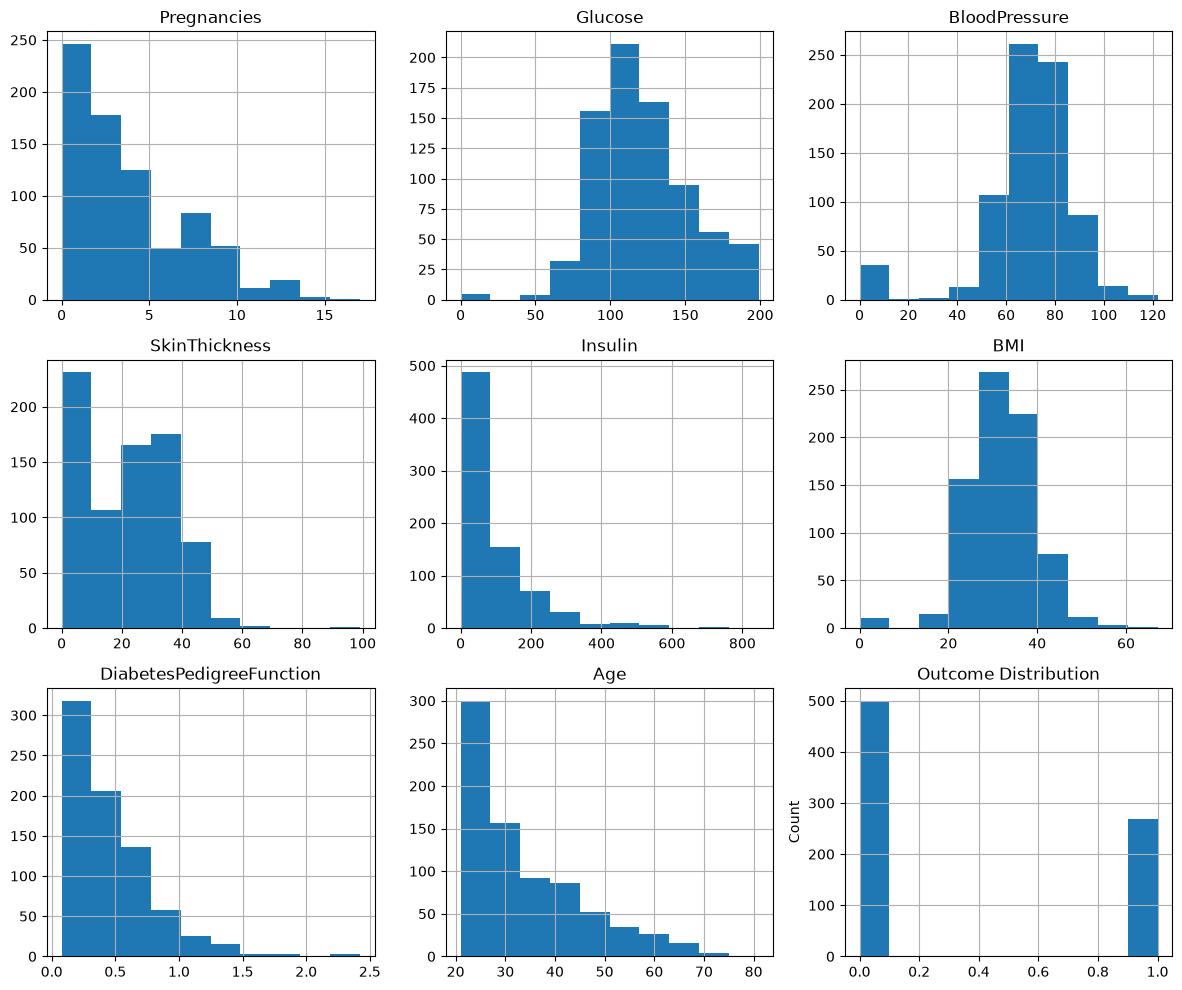

In [11]:
df.hist(figsize=(12, 10))
plt.title('Outcome Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

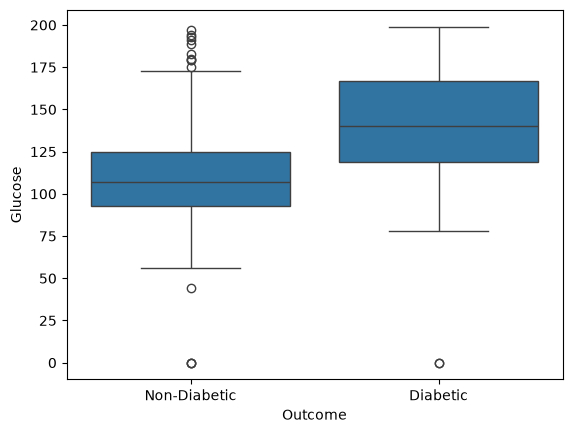

In [12]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

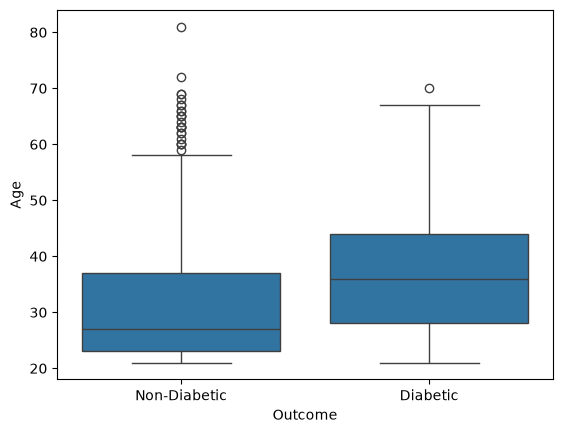

In [13]:
sns.boxplot(x='Outcome', y='Age', data=df)
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

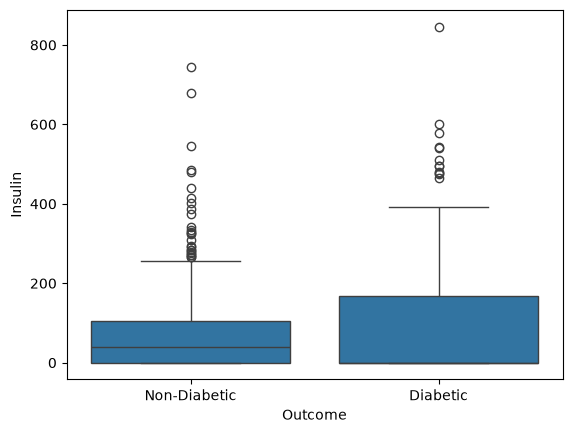

In [14]:
sns.boxplot(x='Outcome', y='Insulin', data=df)
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

# Outlier Analysis (IQR table)    

In [9]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_counts = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
outlier_pct    = (outlier_counts / len(df) * 100).round(2)

outlier_df = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier %'    : outlier_pct
})

print(outlier_df)

                          Outlier Count  Outlier %
Pregnancies                           4       0.52
Glucose                               5       0.65
BloodPressure                        45       5.86
SkinThickness                         1       0.13
Insulin                              34       4.43
BMI                                  19       2.47
DiabetesPedigreeFunction             29       3.78
Age                                   9       1.17
Outcome                               0       0.00


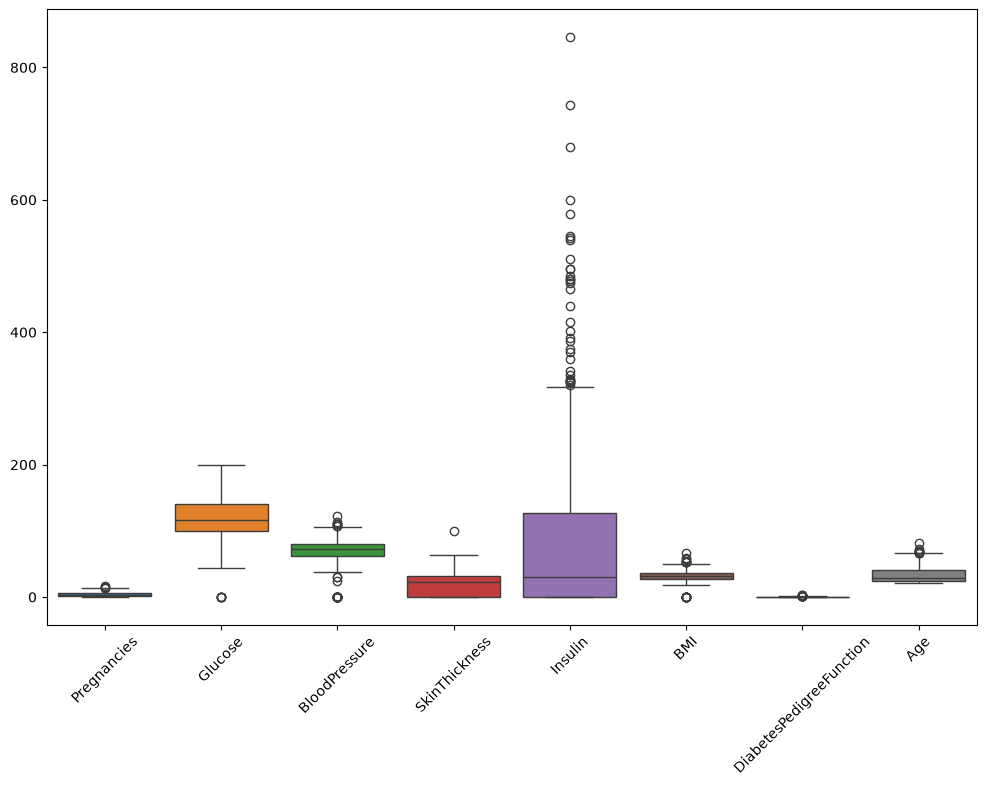

In [15]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.drop('Outcome', axis=1))
plt.xticks(rotation=45)
plt.show()

# Violin plot (DiabetesPedigreeFunction)

Text(0.5, 1.0, 'Diabetes Pedigree Function')

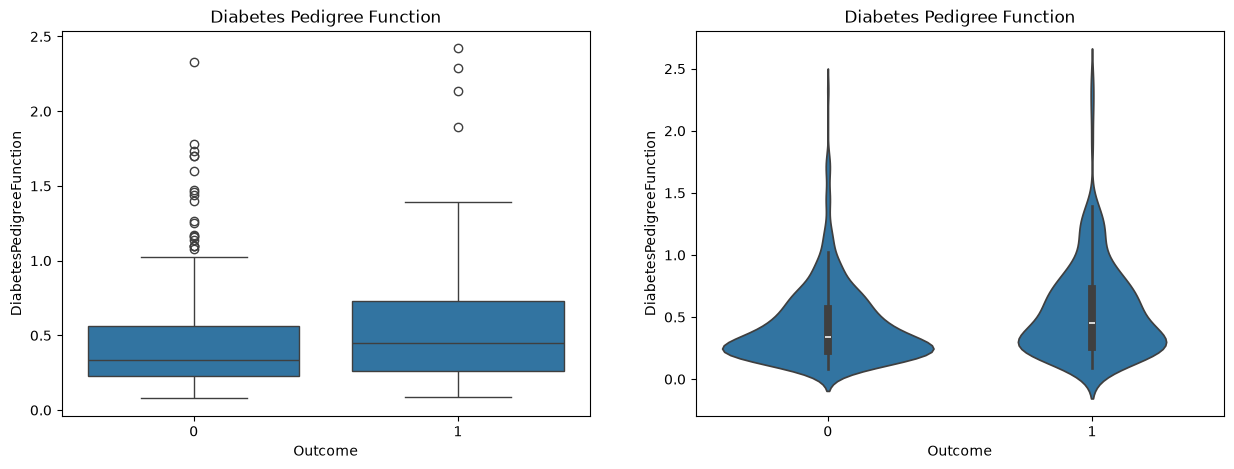

In [16]:
fig,ax = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(x='Outcome',y='DiabetesPedigreeFunction',data=df,ax=ax[0]).set_title('Diabetes Pedigree Function')
sns.violinplot(x='Outcome',y='DiabetesPedigreeFunction',data=df,ax=ax[1]).set_title('Diabetes Pedigree Function')

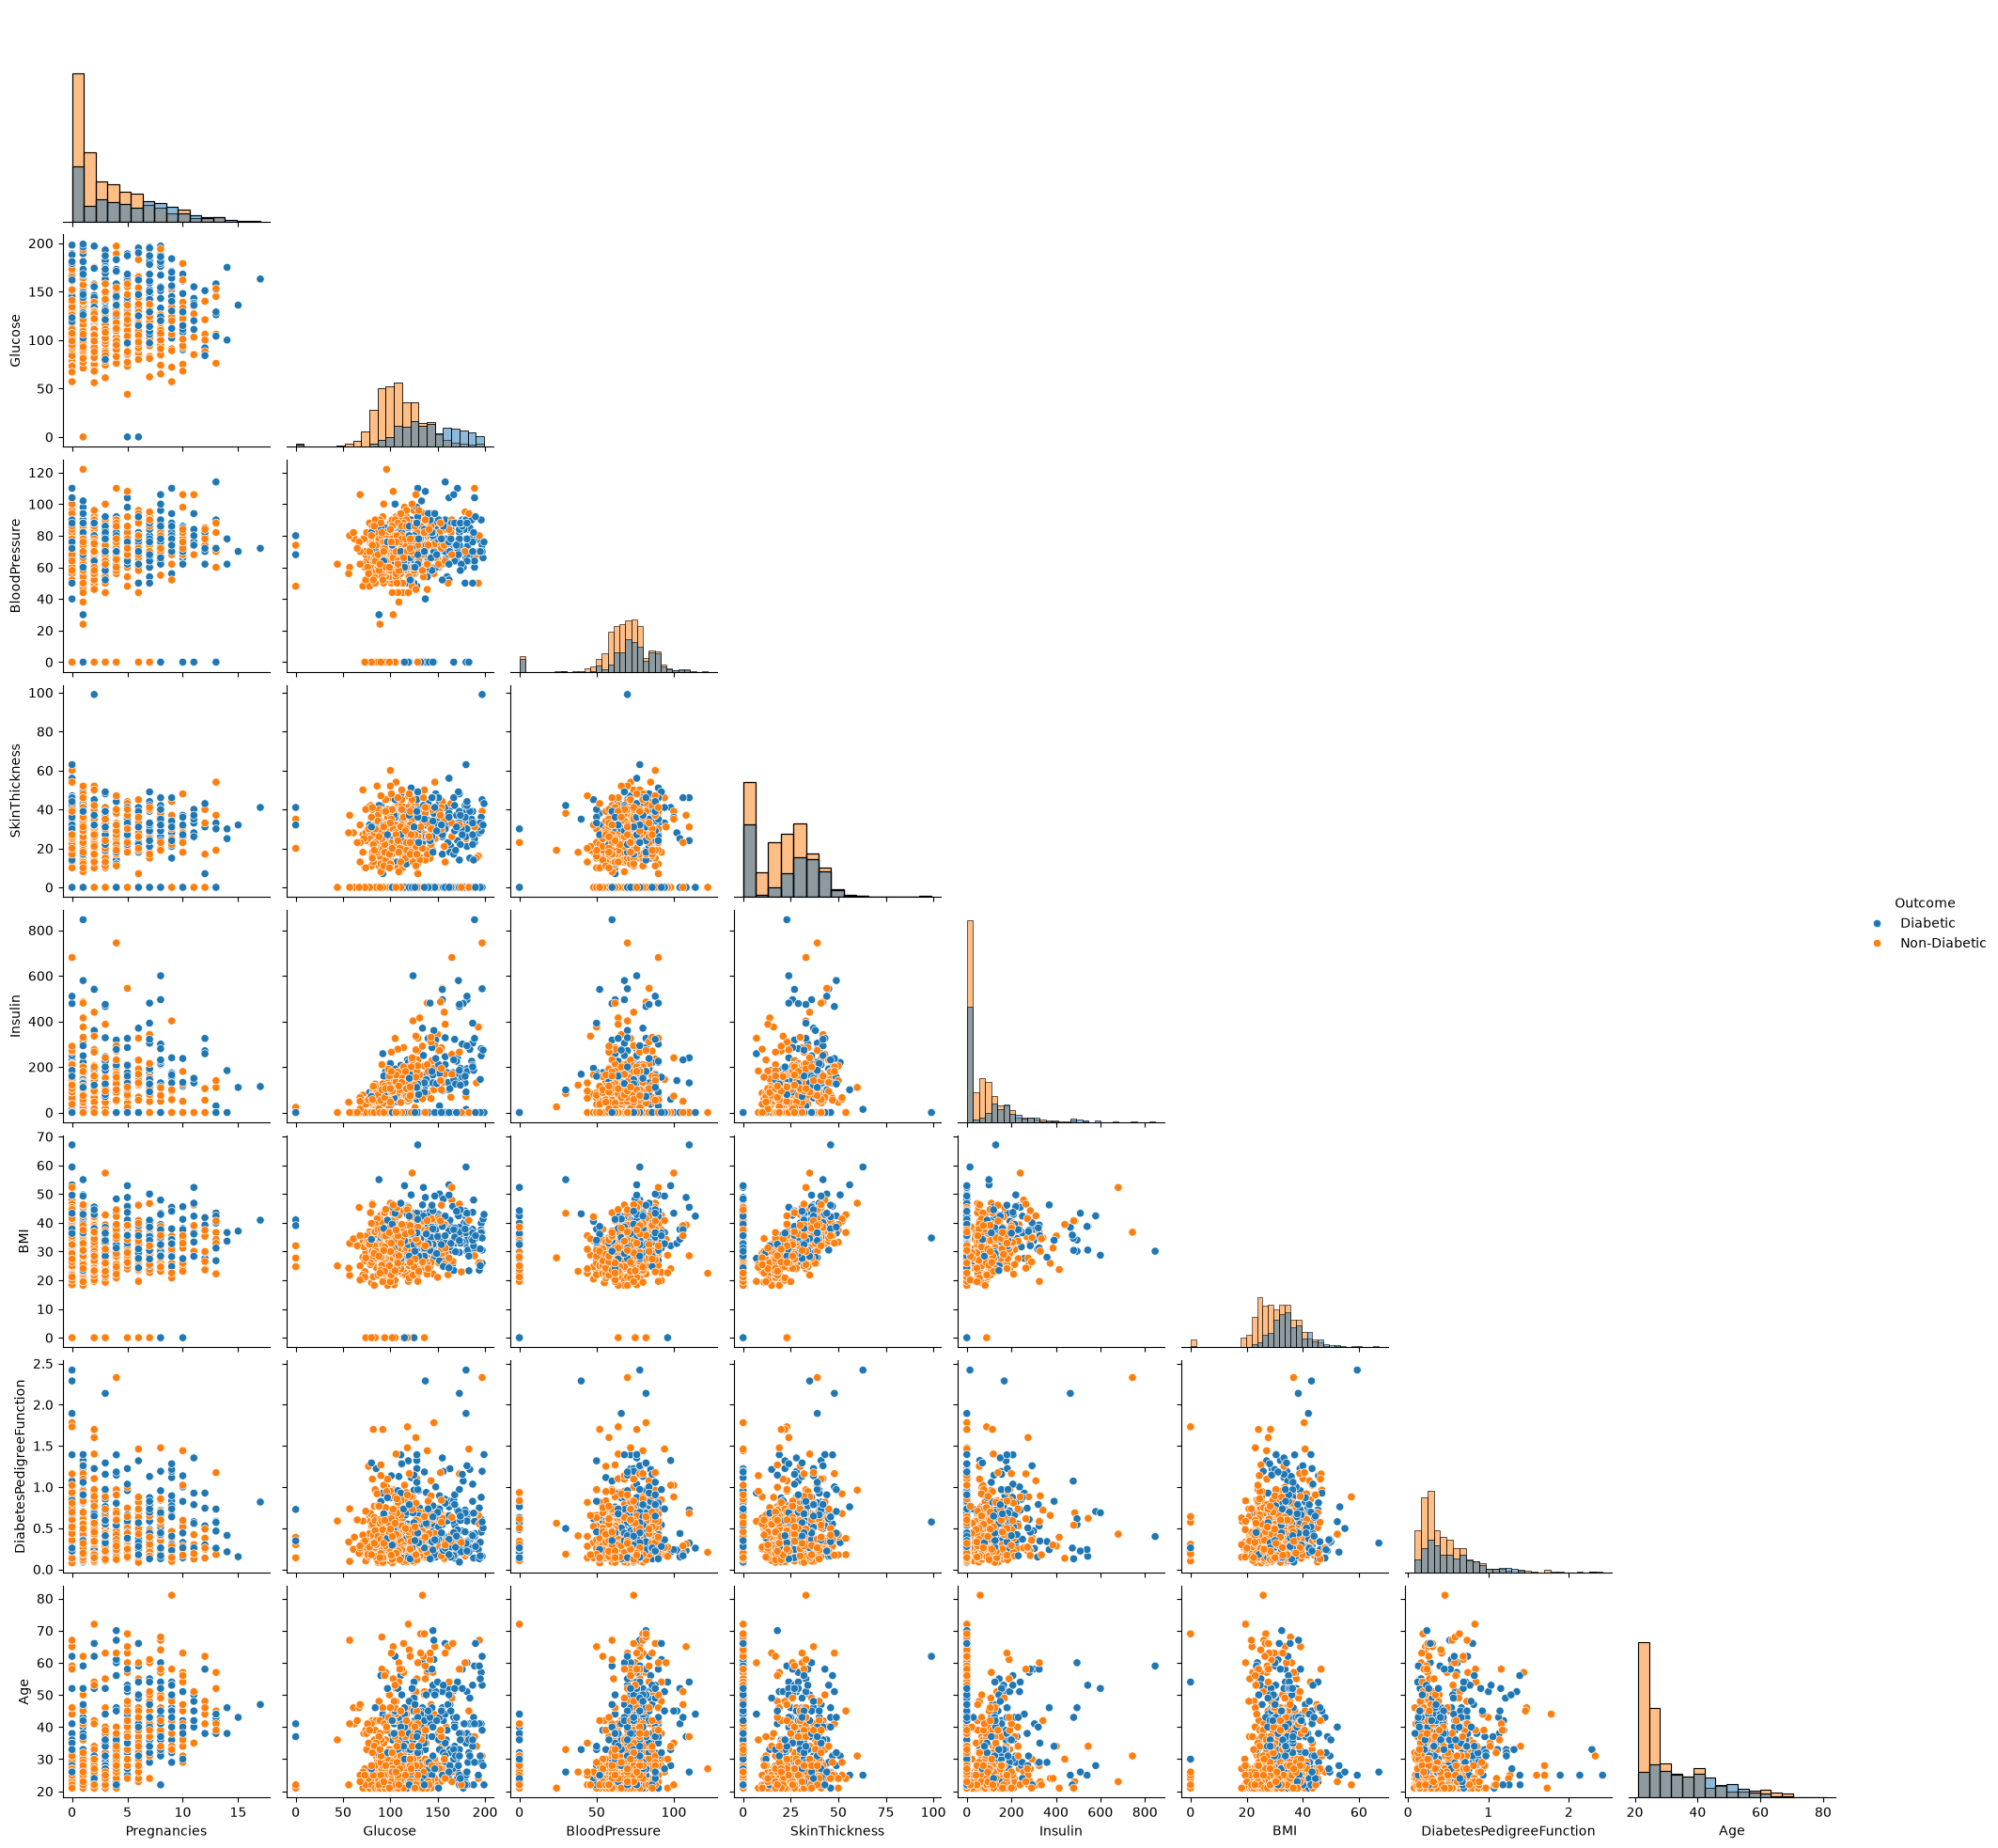

In [ ]:
df_plot = df.copy()
df_plot['Outcome'] = df_plot['Outcome'].map({
    0: 'Non-Diabetic',
    1: 'Diabetic'
})

sns.pairplot(df_plot,hue='Outcome',diag_kind='hist',corner=True)

plt.show()